# Demonstration of Bias and Variance Trade-off

* Here we create a non-linear dataset with two features. 
* Then we fit three models with the dataset to demonstrate how bias and variance affect the accuracy of a model

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score


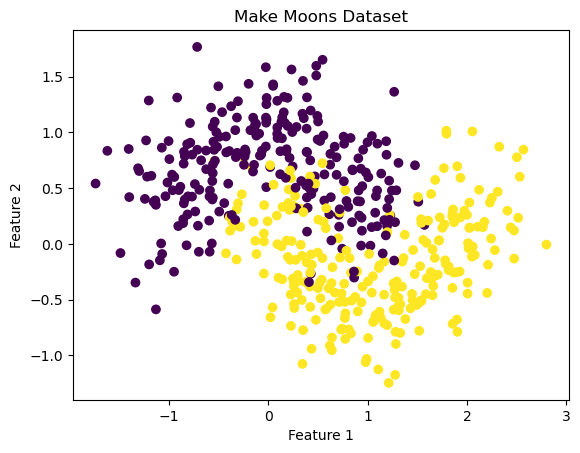

In [2]:
# -----------------------------
# 1. Create a nonlinear dataset
# -----------------------------
X, y = make_moons(n_samples=500, 
                  noise=0.30, 
                  random_state=42)

plt.scatter(X[:, 0], X[:, 1], 
            c=y, 
            cmap='viridis')
plt.title("Make Moons Dataset")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()



In [3]:
# -----------------------------
# 2. Train three models
# -----------------------------


X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y, 
                                                    test_size=0.30, 
                                                    random_state=42)

log_model = LogisticRegression()
tree_shallow = DecisionTreeClassifier(max_depth=3, random_state=42)
tree_deep = DecisionTreeClassifier(max_depth=None, random_state=42)

models = {
    "Logistic Regression": log_model,
    "Decision Tree (max_depth=3)": tree_shallow,
    "Decision Tree (deep)": tree_deep
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)

    results.append((name, train_acc, test_acc))

In [4]:
# -----------------------------
# 3. Print results
# -----------------------------
print("Model Performance Comparison")
print("-" * 50)
print(f"{'Model':30s} {'Train Acc':>10s} {'Test Acc':>10s}")
print("-" * 50)

for name, train_acc, test_acc in results:
    print(f"{name:30s} {train_acc:10.3f} {test_acc:10.3f}")



Model Performance Comparison
--------------------------------------------------
Model                           Train Acc   Test Acc
--------------------------------------------------
Logistic Regression                 0.837      0.860
Decision Tree (max_depth=3)         0.903      0.887
Decision Tree (deep)                1.000      0.853


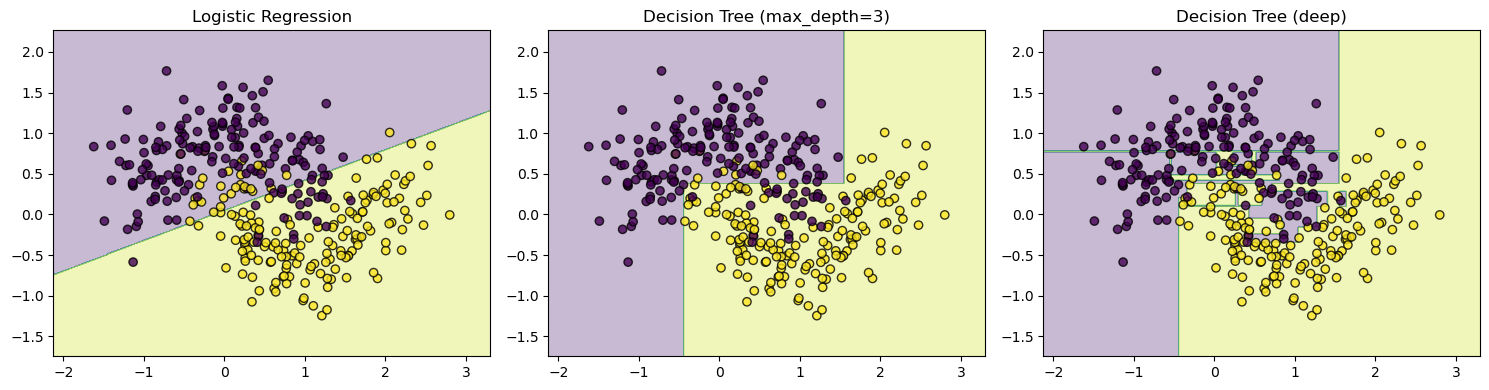

In [5]:
# -----------------------------
# 4. Plot decision boundaries
# -----------------------------
def plot_decision_boundary(model, X, y, ax, title):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.3)
    ax.scatter(X[:, 0], X[:, 1], c=y, edgecolor='k', alpha=0.8)
    ax.set_title(title)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, model) in zip(axes, models.items()):
    model.fit(X_train, y_train)
    plot_decision_boundary(model, X_train, y_train, ax, name)

plt.tight_layout()
plt.show()


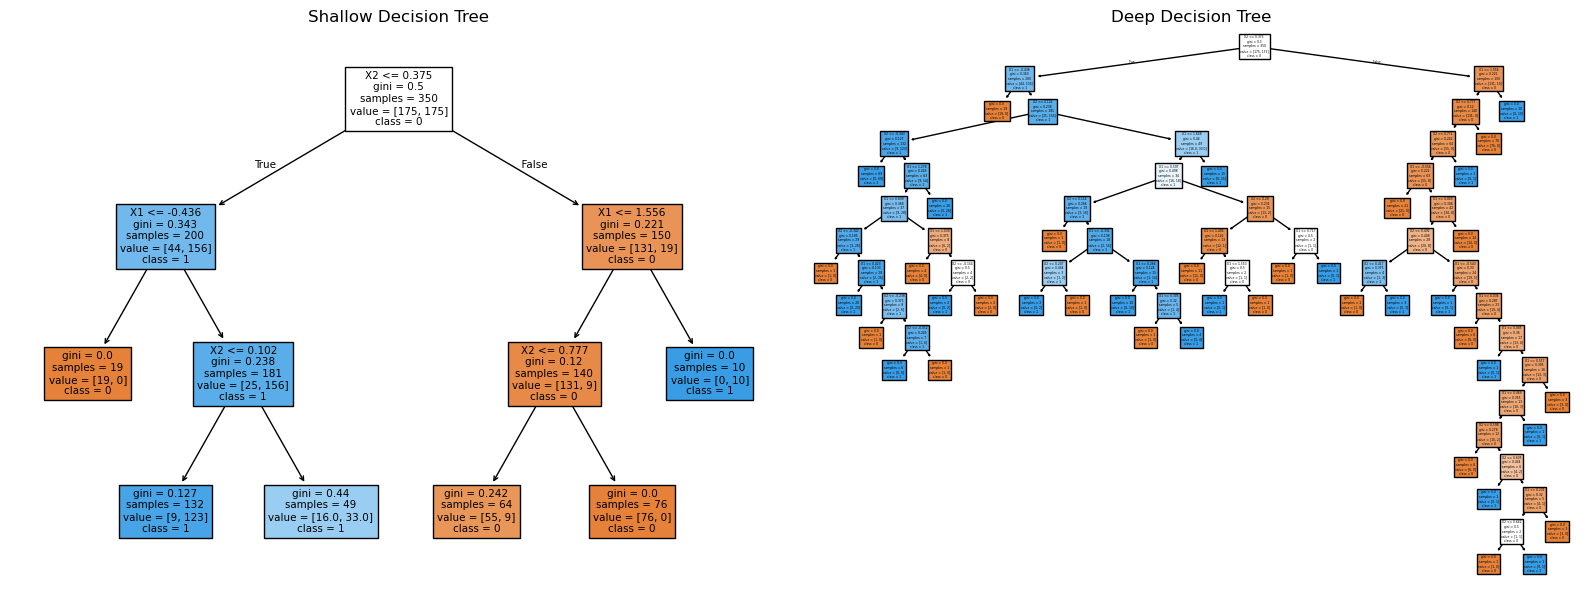

In [6]:
# -----------------------------
# 5. Visualize trees
# -----------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

plot_tree(tree_shallow, filled=True, ax=axes[0], feature_names=["X1", "X2"], class_names=["0", "1"])
axes[0].set_title("Shallow Decision Tree")

plot_tree(tree_deep, filled=True, ax=axes[1], feature_names=["X1", "X2"], class_names=["0", "1"])
axes[1].set_title("Deep Decision Tree")

plt.tight_layout()
plt.show()

# Interpretation of the Result:

* Logistic Regression

    * training accuracy: moderate

    * test accuracy: moderate

    * interpretation: high bias

    * reason: linear model cannot capture the curved boundary well

* Decision Tree (max_depth=3)

    * training accuracy: good

    * test accuracy: good

    * interpretation: better balance of bias and variance

* Decision Tree (deep)

    * training accuracy: very high, often near 1.00

    * test accuracy: lower than training accuracy

    * interpretation: high variance

    * reason: model fits noise and peculiarities of the training set

# Reduce Bias

Polynomial Logistic Regression Comparison
-------------------------------------------------------
Degree    Train Accuracy      Test Accuracy       
-------------------------------------------------------
1         0.854               0.808               
3         0.896               0.900               
10        0.925               0.917               


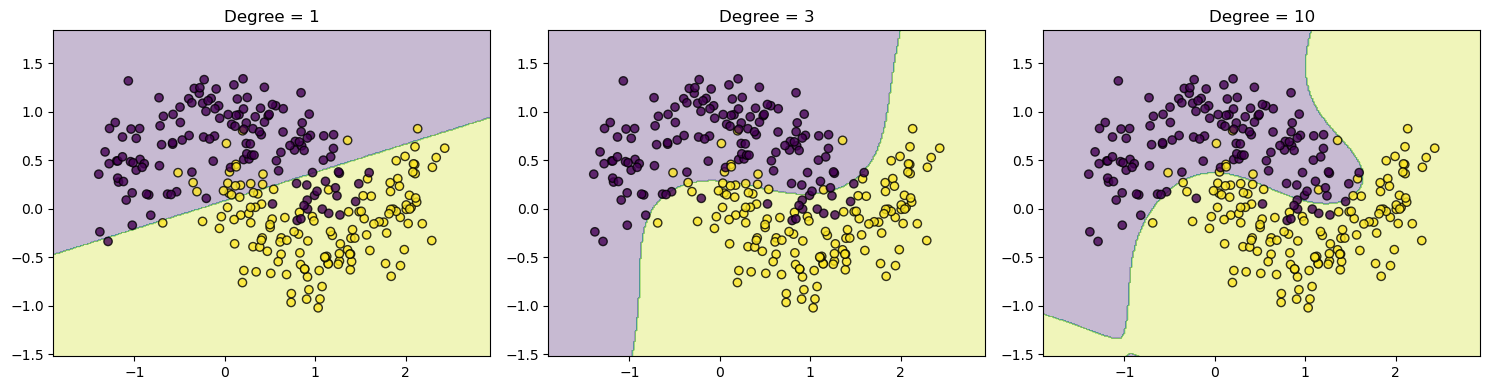

In [9]:
# -- Here, we demonstrate how to reduce bias by using a more complicate model

import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# -------------------------
# 1. Create nonlinear data
# -------------------------
X, y = make_moons(n_samples=400, noise=0.25, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(X, 
                                                    y, 
                                                    test_size=0.30, 
                                                    random_state=42
)

# -------------------------
# 2. Define models
# -------------------------
degrees = [1, 3, 10]
models = {}

for d in degrees:
    model = make_pipeline(
        PolynomialFeatures(degree=d, include_bias=False),
        StandardScaler(),
        LogisticRegression(max_iter=5000)
    )
    model.fit(X_train, y_train)
    models[d] = model

# -------------------------
# 3. Print accuracies
# -------------------------
print("Polynomial Logistic Regression Comparison")
print("-" * 55)
print(f"{'Degree':<10}{'Train Accuracy':<20}{'Test Accuracy':<20}")
print("-" * 55)

for d, model in models.items():
    train_acc = accuracy_score(y_train, model.predict(X_train))
    test_acc = accuracy_score(y_test, model.predict(X_test))
    print(f"{d:<10}{train_acc:<20.3f}{test_acc:<20.3f}")

# -------------------------
# 4. Plot decision boundary
# -------------------------
def plot_boundary(model, X, y, ax, title):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]
    zz = model.predict(grid).reshape(xx.shape)

    ax.contourf(xx, yy, zz, alpha=0.3)
    ax.scatter(X[:, 0], X[:, 1], c=y, edgecolor='k', alpha=0.8)
    ax.set_title(title)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, d in zip(axes, degrees):
    plot_boundary(models[d], X_train, y_train, ax, f"Degree = {d}")

plt.tight_layout()
plt.show()

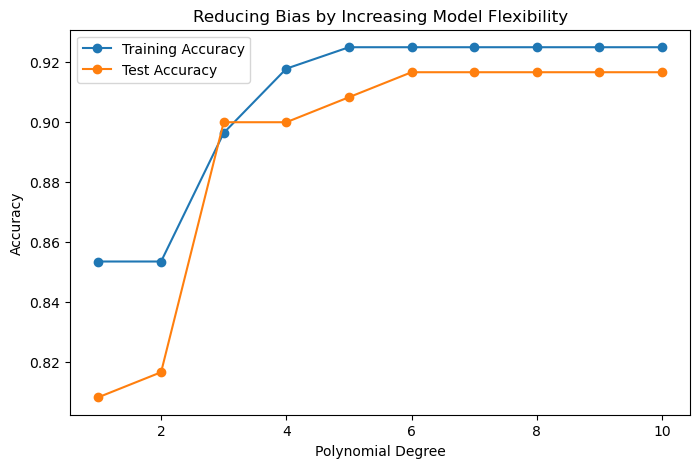

In [8]:
# -- Here we demonstrate how a model's complexity affect bias --

degrees = range(1, 11)
train_scores = []
test_scores = []

for d in degrees:
    model = make_pipeline(
        PolynomialFeatures(degree=d, include_bias=False),
        StandardScaler(),
        LogisticRegression(max_iter=5000)
    )
    model.fit(X_train, y_train)
    
    train_scores.append(model.score(X_train, y_train))
    test_scores.append(model.score(X_test, y_test))

plt.figure(figsize=(8, 5))
plt.plot(degrees, train_scores, marker='o', label='Training Accuracy')
plt.plot(degrees, test_scores, marker='o', label='Test Accuracy')
plt.xlabel("Polynomial Degree")
plt.ylabel("Accuracy")
plt.title("Reducing Bias by Increasing Model Flexibility")
plt.legend()
plt.show()

# Reduces Variance: Random Forest

Model Comparison
--------------------------------------------------
Model                  Train Acc    Test Acc
--------------------------------------------------
Decision Tree              1.000       0.853
Random Forest              1.000       0.900


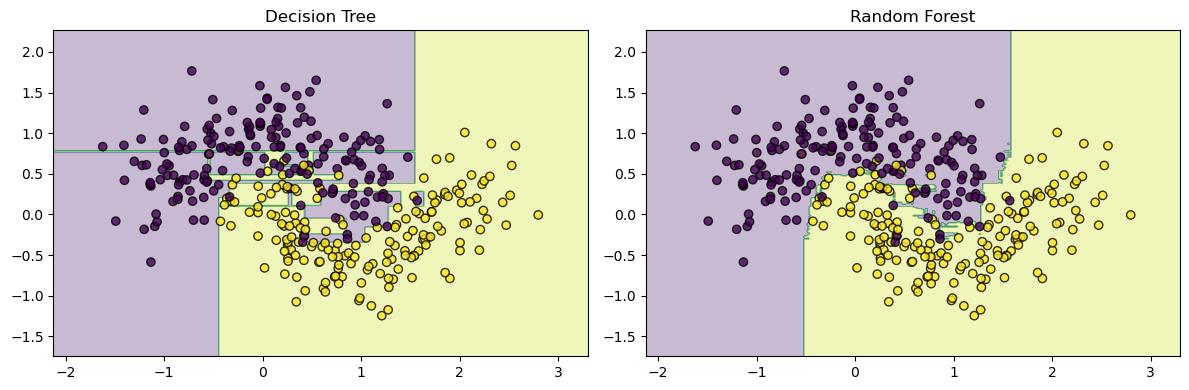

In [10]:
# -- Ensemble approach, like a random forest, can reduce variance. --

import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# ---------------------------------
# 1. Create nonlinear sample data
# ---------------------------------
X, y = make_moons(n_samples=500, noise=0.30, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y, 
                                                    test_size=0.30, 
                                                    random_state=42)

# ---------------------------------
# 2. Define models
# ---------------------------------
tree = DecisionTreeClassifier(random_state=42)
forest = RandomForestClassifier(n_estimators=200, 
                                random_state=42)

models = {
    "Decision Tree": tree,
    "Random Forest": forest
}

# ---------------------------------
# 3. Train and evaluate
# ---------------------------------
print("Model Comparison")
print("-" * 50)
print(f"{'Model':20s}{'Train Acc':>12s}{'Test Acc':>12s}")
print("-" * 50)

for name, model in models.items():
    model.fit(X_train, y_train)

    train_acc = accuracy_score(y_train, model.predict(X_train))
    test_acc = accuracy_score(y_test, model.predict(X_test))

    print(f"{name:20s}{train_acc:12.3f}{test_acc:12.3f}")

# ---------------------------------
# 4. Plot decision boundaries
# ---------------------------------
def plot_decision_boundary(model, X, y, ax, title):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.3)
    ax.scatter(X[:, 0], X[:, 1], c=y, edgecolor='k', alpha=0.8)
    ax.set_title(title)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (name, model) in zip(axes, models.items()):
    plot_decision_boundary(model, X_train, y_train, ax, name)

plt.tight_layout()
plt.show()

**Note**

* Decision Tree

    * training accuracy often very high, sometimes near 1.00
    * test accuracy noticeably lower
    * boundary looks jagged and overly tailored to the training data

* Random Forest

    * training accuracy also high
    * test accuracy often better than the single tree
    * boundary looks smoother and more stable
    
    
    
**Why this demonstrates variance reduction**

* A single decision tree is sensitive to the exact training sample.
* A small change in the data can produce a quite different tree.
* A random forest builds many trees on different bootstrap samples and averages their predictions.
* That averaging reduces sensitivity to noise.

**key point**: One tree can overreact to the training data; many trees averaged together are more stable.

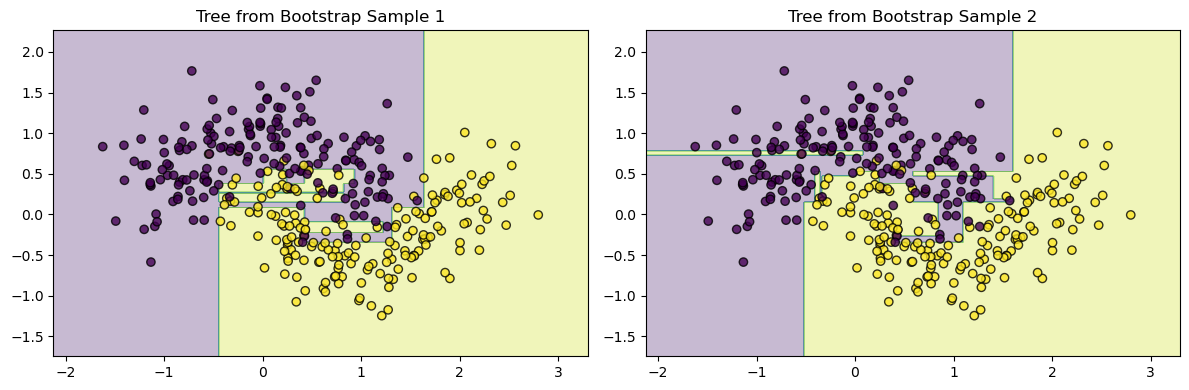

In [11]:
# -- The code below shows how two different single trees trained on different samples 

from sklearn.utils import resample

X_boot1, y_boot1 = resample(X_train, y_train, random_state=1)
X_boot2, y_boot2 = resample(X_train, y_train, random_state=2)

tree1 = DecisionTreeClassifier(random_state=1)
tree2 = DecisionTreeClassifier(random_state=2)

tree1.fit(X_boot1, y_boot1)
tree2.fit(X_boot2, y_boot2)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

plot_decision_boundary(tree1, X_train, y_train, axes[0], "Tree from Bootstrap Sample 1")
plot_decision_boundary(tree2, X_train, y_train, axes[1], "Tree from Bootstrap Sample 2")

plt.tight_layout()
plt.show()